# Time Series Terminologies


## Prerequisites:

To start Time Series Terminologies, you must have a proper understanding of the following concepts:

- Time Series
- Statistical Time Series model
- Stochastic Process
- Expectation 
- Correlation and Covariance 


## Learning Objective:

- Understand the concept of autocovariance, autocorrelation and sample autocorrelation 

- Understand the concepts of strict stationarity and weak stationarity 

- Understand the concepts of partial autocorrelation and sample partial autocorrelation

- Understand the concept of ACF and PACF graphs


In the previous chapters, you learned about several ML terminologies and some basic TSA methods. While many of those terminologies are common in time series, we still have some terminologies that are quite specific to the time series domain. In this chapter, we will discuss in details about some important time series concepts such as autocovariance and autocorrelation, stationarity, partial autocorrelation, and autocorrelation function (ACF) and partial autocorrelation function (PACF) graphs. 


## Autocovariance and  Autocorrelation

In the previous chapter, we talked about the statistical time series model. This model formulates a time series $X$ as the collection of random variables over time. Let's say the mean of the random variable at arbitrary timestamp $t$ is $\mu_t$

i.e.  

$$
\newcommand{\E}[1]{\mathbb{E} [#1]}
\E{X_t} = \mu_t.
$$

\\

If the covariance between any two variables is zero, we can infer that the variables are independent. We stated earlier that the $iid$ assumption we have in most conventional ML techniques no longer hold in time series. It's because some non zero covariance is present between any two variables at different timestamps in the time series. Since the covariance is between the variables at different timestamps of a single time series, we call this autocovariance, meaning self covariance or covariance with itself. Let's define autocovariance formally. 


For a time series $X$, the autocovariance between the variables at timestamps $s$ and $t$, denoted by $\gamma_{X} (s, t)$ is defined as: 

$$ 
\gamma _{X} (s, t) = \text{cov} (X_s, X_t) = \E{(X_s - \mu _s)(X_t - \mu _t)}$$

When there's no possible confusion about which time series we refer to, we drop the subscript $X$. So $\gamma (s, t)$ will be used further to denote the autocovariance between timestamps $s$ and $t$ for the time series $X$. 

\\

Similarly, the autocorrelation between the variables at timestamps $s$ and $t$, is denoted by $\rho (s, t)$ and defined as:

$$ \rho (s, t) = \frac{\gamma (s, t)} {\sqrt{\gamma (s, s) \gamma (t, t)}}$$


## Stationarity

In statistical time series model, we didn't specify any criterion for the random variables $X_0, X_1, ...,X_T$ of the process. The space of random variables where they can have any statistical form is a very huge space. Let's constraint the process to have same statistical properties over all the timestamps. In other words, the statistical properties of the data generating process don't change over time. But it does not mean that the time series generated by this process doesn't change at all. It just means that the way the observed values change over time remains the same. This sub-class of time series processes are eaiser to model and investigate. Many TSA models we'll study in this module require the data to be stationary. Let's define stationarity formally next.


### Strict Stationarity

If a time series is defined to be strictly stationary, then the probabilistic behaviour of all the possible subsets of the variables must be identical to that of the corresponding subset with time shifted variables.

#### Mathematical Definition

>A time series $X = \{X_t = x_t \}_{t = 0} ^{T}$ is said to be strictly stationary if every set of variables 
$$\{X_{t1}, X_{t2}, ..., X_{tk}\}$$
is probabilistically identical to the set of time shifted variables $$\{X_{t_1 + h}, X_{t_2 + h},  ..., X_{t_k + h}\}.$$
i.e. 
$$\Pr(X_{t_1} \le c_{1} , X_{t_2} \le c_{2}, ..., X_{t_k} \le c_{k}) = \Pr (X_{t_1 + h} \le c_{1}, X_{t_2 + h} \le c_{2} , ..., X_{t_k + h} \le c_{k})$$
${ 
\forall \ \text{set length} \ k = 1, 2, 3, ..., T + 1,\\ 
\forall \ \text{time points} \ t_1, t_2, ..., t_k,\\
\forall \ \text{numbers} \ c_1, c_2, ..., c_k,\\
\forall \ \text{shifts} \ h = 0,1, 2, ..., T.\\
}
$

Note that the $X_{t_1}, X_{t_2}, ..., X_{t_k}$ need not be consecutive variables. The freedom to choose any values of numbers $c_1, c_2, \ldots, c_k$ infers the subsets to be probabilistically equal. The shift infers that the time-series doesn't change its property wheresoever we look into the series, be it in the early beginning or the end of the series. Also, the property has to be followed by every possible subset. Let's see what we can break down by using $k = 1$ and $k = 2$.   

\\

At $k = 1$,
$$\Pr (X_t \le c) = \Pr (X_{t+h} \le c) \quad  \forall t \ \forall h \ \forall c$$

This implies that the mean of $X_t$ is equal to the mean of $X_{t + h}$ or, 
$$\mu_t = \mu_{t + h} \quad \forall h.$$ 

\\

At $k = 2$, 
$$\Pr (X_s \le c_1, X_t \le c_2) = \Pr (X_{s + h} \le c_1, X_{t + h} \le c_2) \quad \forall h \ \forall s \ \forall t \ \forall c_1 \ \forall c_2 $$

This equation implies that the autocovariance between two variables at some distance will be equal to the autocovariance between two variables at the same distance at different time points or
$$\gamma (s, t) = \gamma(s + h, t + h) \quad \forall s \ \forall t \ \forall h$$







### Weak Stationarity

The strict stationarity is a very strong property and not required in most applications. Rather than allowing all the possible subsets of the variables, we can restrict to a relatively weaker class that imposes conditions on only the first two moments (mean and autocovariance). 


#### Mathematical Definition
>A time series $X = \{ x_t \}_{t=0} ^{T}$ is said to be weakly stationary if:
1. Mean of $X_t$ is independent of t and is constant i.e. $$\mu_t = \mu_{t + k} = \mu \quad \forall t \ \forall k.$$
2. Autocovariance $\gamma (s, t)$ depends only on $s$ and $t$ thorugh $|t - s|$ i.e.
$$\gamma(s, t) = \gamma(s + k, t + k) = \gamma (0, t - s) = \gamma_{|t-s|} \quad \forall s \ \forall t \ \forall s \ \forall k.$$

In other words, the mean of variables at every timestamp is the same and the autocovariance is the function of the difference in timestamps only. Let's define this notion of autocovariance with **lag**. For a variable at time $t$ $X_t$, the variable $h$ timestamps prior to it $X_{t-h}$ is called the $h$-th lag of $X_t$. Hence, we can say autocovariance is the function of lag $h$. 


## Sample Autocovariance and  Sample Autocorrelation

Note that we cannot calculate autocorrelation between variables exactly by observing a single sequence/time-series as defined earlier. Autocorrelation as discussed earlier is a function of the underlying data generation process. However, if the time series seem to be stationary (i.e. do not have significant trend and seasonality), we can assume the process is stationary. Using the conditions of constant mean and constant autocovariance between the variables for stationary process, we can define sample autocovariance and sample autocorrelation. 

For a stationary time series, since the mean is constant (i.e., $\mu_t = \mu$), we can estimate the mean of the time series by the sample mean as:

$$
\hat{\mu} = \frac {\sum _{t = 0} ^T {x_t}} {T + 1}.
$$

Also, for stationary time series, the autocovariances between the variables at timestamps of interval $h$ must be the same. Hence, we can define the sample autocovariance as function of lag $h$ as: 

$$
\hat{\gamma}(h) = \frac{\sum _{t=0} ^{T - h}{(x_t - \hat{\mu}) (x_{t+h} - \hat{\mu}})}{T + 1}.
$$

Since the value is calculated using the samples or observations over the timestamps, we call it sample autocovariance. Similarly, for stationary time series, the sample autocorrelation is also the function of lag $h$ only. It's denoted by $\hat{\rho}(h)$ and defined as:

$$
\hat{\rho}(h) = \frac{\hat{\gamma}(h)} {\hat{\gamma}(0)}.
$$

 


## Partial autocorrelation

For a stationary time series $X$, the partial autocorrelation, denoted by $\phi_{hh}$ is defined as:

$$
\phi_{hh} = 
\begin{cases}
    \text{corr}(X_t, X_{t - 1}) = \rho(1), & h = 1\\
    \text{corr}(X_t - \hat{X}_{t}, X_{t - h} - \hat{X}_{t - h}),               & h \ge 2
\end{cases}
$$

where,

$
\hat{X}_{t} = \beta_0 + \beta_1 X_{t-1} + \beta_2 X_{t-2} + ... +  \beta_{t - h + 1} X_{t - h + 1} 
\\
\hat{X}_{t - h} = \beta_0 + \beta_1 X_{t - h + 1} + \beta_2 X_{t- h + 2} + ... +  \beta_{t - 1} X_{t - 1}
$

Here, $\hat{X}_{t}$ and $\hat{X}_{t - h}$ denote the linear regression of $X_t$ and $X_{t - h}$ respectively on the variables in between the timestamps $t$ and $t - h$. Hence, $\phi_{hh} = \text{corr}(X_t - \hat{X}_{t}, X_{t - h} - \hat{X}_{t - h})$ denotes the correlation between $X_t$ and $X_{t-h}$ after removing their linear dependence on the variables in between. 




## ACF and PACF graphs

Some TSA models use autocorrelations and partial autocorrelations at different lags to understand the underlying data generation process's nature. You'll study such models in the next unit. Well, we have observed the formulae to get the values for autocorrelations and partial autocorrelations. In the literature, however, we use different notations: ACF and PACF. ACF stands for AutoCorrelation Function, while PACF stands for Partial AutoCorrelation Function. These are the functions popular in the R times series analysis package called `tsa`.  Usually, we generate the values using these functions and plot the graphs, which we use for further analysis.  

Let's see ACF and PACF graphs for random data. We'll use  [`statsmodels`](https://www.statsmodels.org/stable/index.html) library to generate the graphs.  


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [ ]:
# generate 1000 samples of random data 
X = np.random.randn(1000)

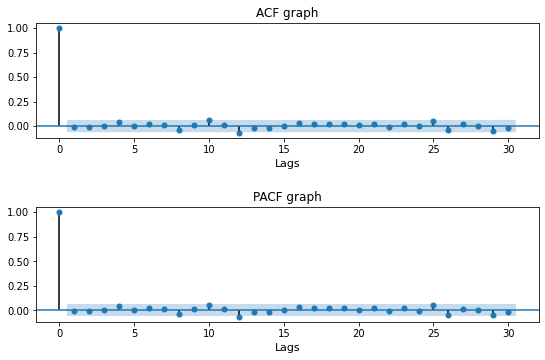

In [ ]:
fig = plt.figure(figsize=(9, 5.5))
fig.subplots_adjust(hspace=0.6)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

# plot ACF graph
sm.graphics.tsa.plot_acf(X, ax=ax1, title='ACF graph')
ax1.set_xlabel('Lags', fontsize=11)

# plot PACF graph
sm.graphics.tsa.plot_pacf(X, ax=ax2, title='PACF graph')
ax2.set_xlabel('Lags', fontsize=11)
plt.show()

Both autocorrelation and partial autocorrelation values are small at lags $1, 2, ...$. It's because the data we have taken is random, and thus the values won't be correlated. We'll see cases where the values will be significantly large for larger lags too in the next unit. 


## Key Takeaways

1. Autocovariance and autocorrelation represent the dependence between the variables of the statistical time series model at different timestamps. 

2. For a time series to be strictly stationary, any set of values must be probabilisitcally identical to the set of corresponding time shifted values.

3. Weak stationarity is a weaker form of stationarity which infers the mean of the random variables is same and the autocovariance is the function of lag only.

4. Partial autocorrelation between any two variables at timestamps $t$ and $t-h$ is the correlation between the variables after removing their linear dependence on the variables in between.

5. ACF and PACF are the functions to obtain autocorrelations and partial autocorrelations. These are the names used in the literature in general.


## References

- Shumway R., Stoffer D. (2016) Time Series Analysis and Its Applications: With R Examples, 4th edition, Springer
    * Check chapter 1.4 in page 19 for more information on stationary time series.
